In [187]:
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt

input/woman.tiff  exists!


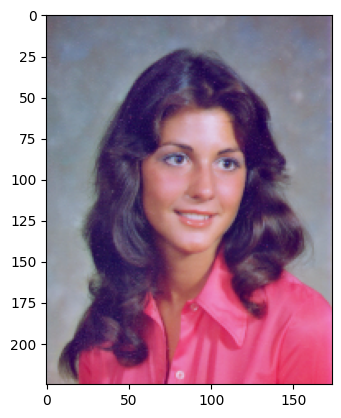

In [188]:
file_ = 'input/woman.tiff'
if os.path.isfile(file_) : print(file_, " exists!") # is ok!!
img = cv2.imread(file_) 
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

In [189]:
def show_bgr_image(image):
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

1. Input images

### Read and convert images to rgb


In [190]:
input_folder = 'input\\misc'
images_paths = list(os.listdir(input_folder)) 
images_paths = [os.path.join(input_folder, file_name) for file_name in images_paths]+ ['input\\woman.tiff', 'input\\lena.jpg']
images = [cv2.imread(image_path) for image_path in images_paths]
# images = [cv2.cvtColor(img, cv2.COLOR_BGR2RGB) for img in images] # convert the images to rgb images

### Save 2 rectangular images

In [191]:
rectangular_images = [img for img in images if img.shape[0] != img.shape[1]]
image_file_names = ["ps0-1-a-1.png","ps0-1-a-2.png"]
for i,rec_image in enumerate(rectangular_images[:2]):
    img_full_path = f"output/{image_file_names[i]}"
    cv2.imwrite(img_full_path, rec_image)

2. Color Planes

### Replace BGR to RGB and save


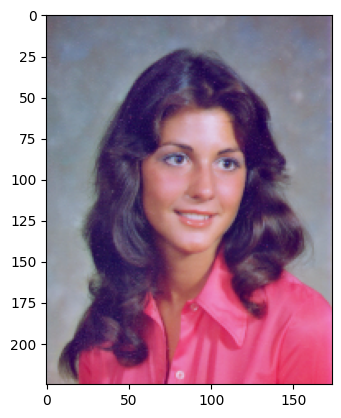

In [192]:
rectangular_images[0] = cv2.cvtColor(rectangular_images[0], cv2.COLOR_BGR2RGB)
cv2.imwrite("output/ps0-2-a-1.png", rectangular_images[0])
plt.imshow(rectangular_images[0])


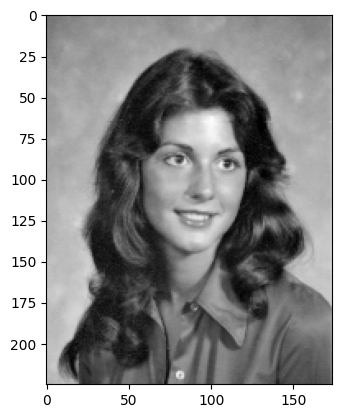

In [193]:
img1_green = rectangular_images[0].copy()
img1_green = img1_green[:,:,1]
cv2.imwrite("output/ps0-2-b-1.png", img1_green)
plt.imshow(img1_green, cmap="gray")

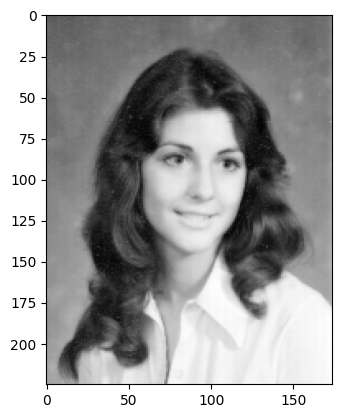

In [194]:
img1_red = rectangular_images[0]
img1_red = img1_red[:,:,0]
cv2.imwrite("output/ps0-2-b-1.png", img1_red)
plt.imshow(img1_red, cmap="gray")

In [195]:
def slice_inner_square(image, size=100, image2=None):
    # Get image dimensions
    if len(image.shape) == 3:
        height, width, _ = image.shape
    else:
        height, width = image.shape


    # Calculate center coordinates
    center_y = height // 2
    center_x = width // 2

    # Define the bounding box for the inner square
    size = 100
    top_left_y = center_y - size // 2
    top_left_x = center_x - size // 2
    bottom_right_y = center_y + size // 2
    bottom_right_x = center_x + size // 2

    # Ensure the bounding box stays within image boundaries
    top_left_y = max(top_left_y, 0)
    top_left_x = max(top_left_x, 0)
    bottom_right_y = min(bottom_right_y, height)
    bottom_right_x = min(bottom_right_x, width)

    # Extract the inner square region
    inner_square = image[top_left_y:bottom_right_y, top_left_x:bottom_right_x]

    if image2 is not None:
        # Insert into image2
        image2[top_left_y:bottom_right_y, top_left_x:bottom_right_x] = inner_square
        return image2
    

    return inner_square

3. Replacement of pixels

### Cut the better image into the worse image out of the two single-channeled images

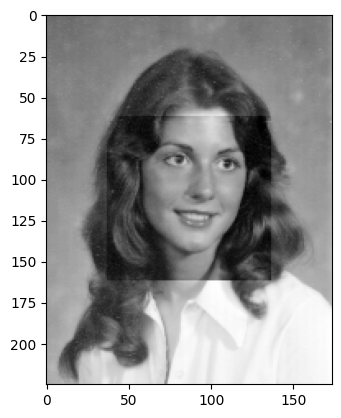

True

In [196]:
img1 = img1_green.copy()
img2_with_img1 = slice_inner_square(img1,100, img1_red.copy())
plt.imshow(img2_with_img1, cmap='gray')
plt.show()
cv2.imwrite("output/ps0-3-a-1.png", img2_with_img1)

4. Arithmetic and Geometric operations

In [197]:
print(f"min: {img1_green.min()}")
print(f"max: {img1_green.max()}")
print(f"mean: {img1_green.mean()}")
print(f"std: {img1_green.std()}")

min: 0
max: 212
mean: 98.78710089399745
std: 48.59562875136795


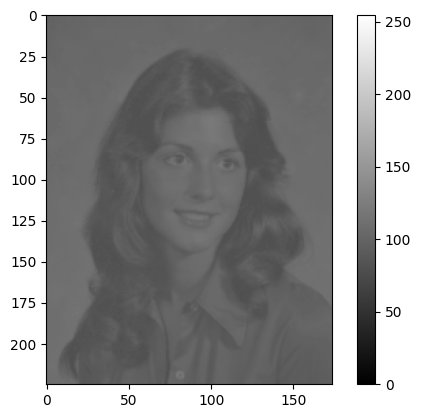

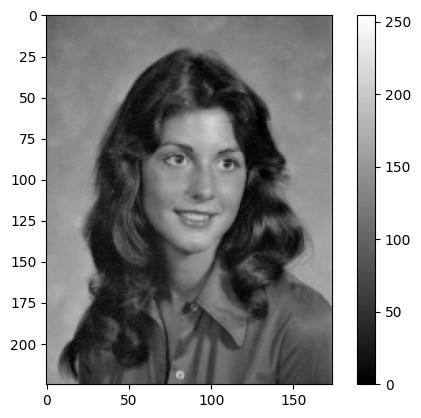

True

In [198]:
img1_processed = ((img1_green - img1_green.mean())/img1_green.std()) * 10.0 + img1_green.mean()
# show_bgr_image(img1_processed)
plt.imshow(img1_processed, cmap="gray",vmin=0,vmax=255)
plt.colorbar()
plt.show()
plt.imshow(img1_green, cmap="gray",vmin=0,vmax=255)
plt.colorbar()
plt.show()
cv2.imwrite("output/ps0-4-b-1.png", img1_processed)

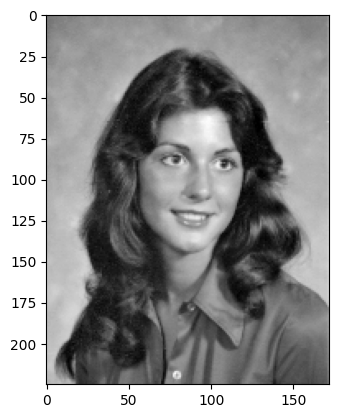

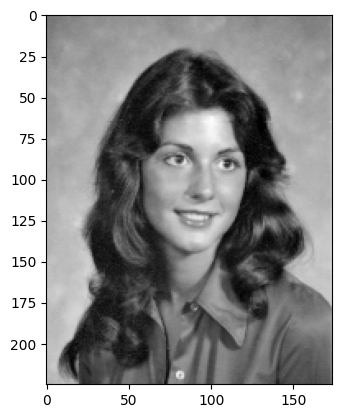

True

In [199]:
# shift image left by 2
img1 = img1_green[:,2:]
height, width = img1_green.shape
black_column = np.zeros((height, 2), dtype=np.uint8)
img1_shifted = np.concatenate([img1,black_column], axis=1)
plt.imshow(img1,cmap="gray")
plt.show()
plt.imshow(img1_green,cmap="gray")
plt.show()
cv2.imwrite("output/ps0-4-c-1.png", img1_processed)



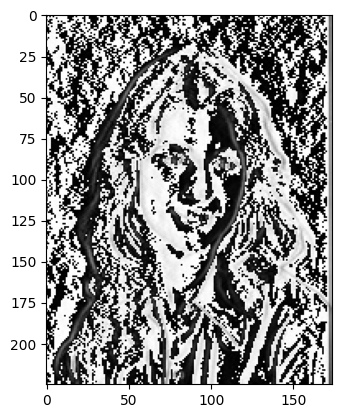

True

In [221]:
diff_img = img1_green - img1_shifted
# print(diff_img)
plt.imshow(diff_img,cmap="gray")
plt.show()
cv2.imwrite("output/ps0-4-d-1.png", diff_img)


### Noise

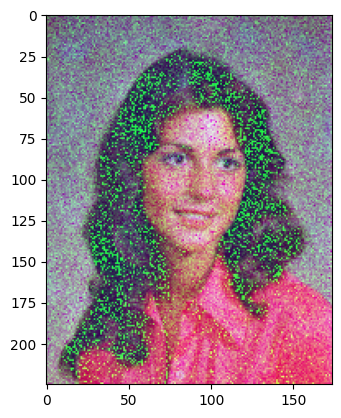

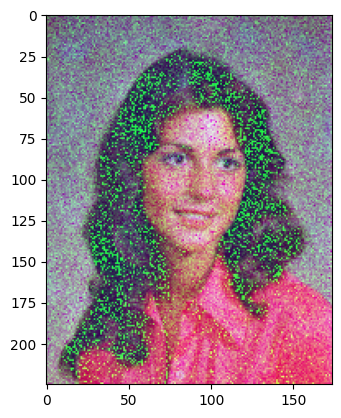

True

In [243]:
mean = 0
std_dev = 20
original_image = rectangular_images[0]
gaussian_noise = np.random.normal(mean, std_dev, original_image.shape[:2])


img_with_noise = original_image.copy()
channel=1
img_with_noise[:,:,channel] = img_with_noise[:,:,channel] + gaussian_noise
img_with_noise[:,:,channel] = img_with_noise[:,:,channel] + gaussian_noise
plt.imshow(img_with_noise)
plt.show()
cv2.imwrite("output/ps0-5-a-1.png", img_with_noise)

# blue channel
img_with_noise = original_image.copy()
channel=1
img_with_noise[:,:,channel] = img_with_noise[:,:,channel] + gaussian_noise
img_with_noise[:,:,channel] = img_with_noise[:,:,channel] + gaussian_noise
plt.imshow(img_with_noise)
plt.show()
cv2.imwrite("output/ps0-5-b-1.png", img_with_noise)


0 212 98.78710089399745


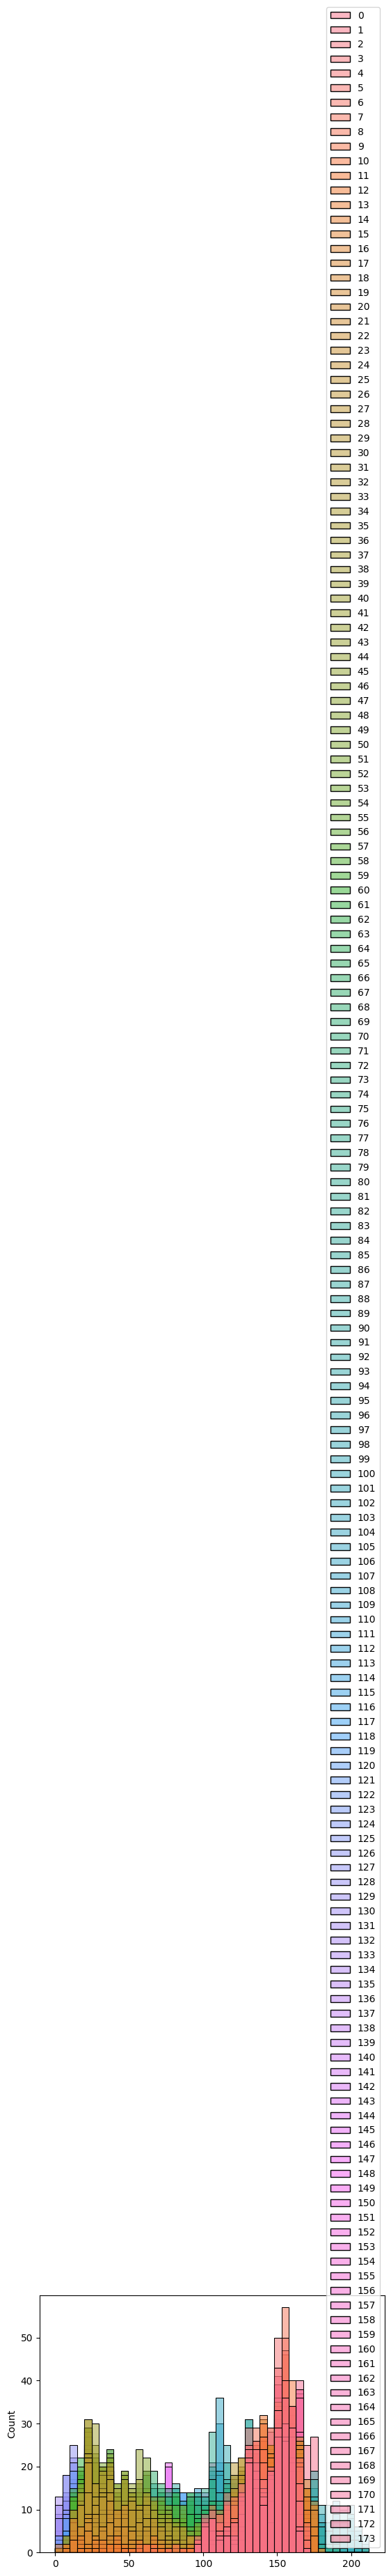

In [239]:
import seaborn as sns
channel = 1
print(original_image[:,:,channel].min(), original_image[:,:,channel].max(), original_image[:,:,channel].mean())
# sns.hist(original_image[:,:,channel], bins=5)
plt.show()
sns.histplot(original_image[:,:,1], )
plt.show()
